In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('/content/data.csv')

In [3]:
df = df.drop(columns=['id', 'Unnamed: 32'])

In [4]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [5]:
print("Dataset successfully loaded. Shape:", df.shape)
df.head()

Dataset successfully loaded. Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Split the data into training and testing sets and perform feature scaling.
# KNN is highly sensitive to the scale of data (Euclidean distance calculation).

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# 70% Training, 30% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling features to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaling complete.")

Data split and scaling complete.


In [7]:
# Implement the Standard KNN model using the parameters suggested in the research paper.
# As per Zhang (2016), we use Euclidean distance and a tuned k-value.

k_value = 15 # Optimal value identified in Zhang's working example [cite: 301]
knn_std = KNeighborsClassifier(n_neighbors=k_value, weights='uniform', metric='euclidean')
knn_std.fit(X_train_scaled, y_train)

y_pred_std = knn_std.predict(X_test_scaled)

print("Standard KNN Accuracy:", accuracy_score(y_test, y_pred_std))
print("Standard KNN Kappa:", cohen_kappa_score(y_test, y_pred_std))

Standard KNN Accuracy: 0.9532163742690059
Standard KNN Kappa: 0.8981233243967829


In [8]:
# PROMPT: Extend the paper by implementing Weighted KNN to improve accuracy.
# Extension: Weighting neighbors by the inverse of their distance to give closer neighbors more influence.

knn_weighted = KNeighborsClassifier(n_neighbors=k_value, weights='distance', metric='euclidean')
knn_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = knn_weighted.predict(X_test_scaled)

print("Weighted KNN Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("Weighted KNN Kappa:", cohen_kappa_score(y_test, y_pred_weighted))

Weighted KNN Accuracy: 0.9590643274853801
Weighted KNN Kappa: 0.9111556446225785


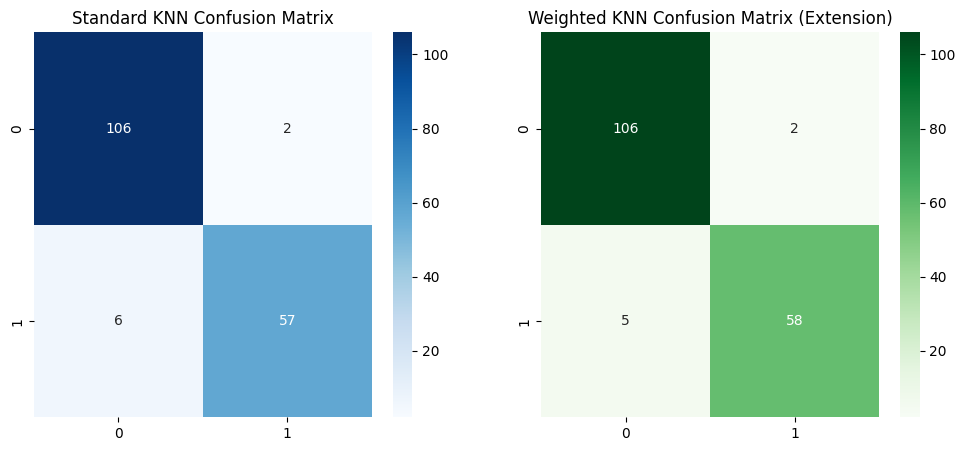

In [9]:
# PROMPT: Compare the results visually using a Confusion Matrix.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_std), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Standard KNN Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, y_pred_weighted), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('Weighted KNN Confusion Matrix (Extension)')

plt.show()